# Warden v2: do motor de regras ao controlador fuzzy

Esta e a versao 2 do [Warden](cyber_warden.ipynb): as celulas abaixo, ate
"Autoverificacao", **sao identicas** ao motor de regras original (mesmos
Facts, mesmas regras, mesmo motor de encadeamento progressivo, mesmo cenario
de demonstracao). Nada disso foi reescrito.

A partir de "Controlador fuzzy Mamdani", o notebook acrescenta uma camada
nova: em vez de so uma decisao crisp (`ISOLAR`/`MONITORAR`/nenhuma), a mesma
evidencia bruta de cada host — as mesmas `Conexao` e `Arquivo` da secao
acima, com os mesmos limiares `EXPEDIENTE` e `LIMITE_EXFILTRACAO` — alimenta
um controlador fuzzy Mamdani que produz uma prioridade continua de 0 a 10.
As duas leituras (crisp e fuzzy) sao comparadas lado a lado no final.

Encadeamento progressivo em cadeia: **evidencia -> indicador -> ameaca -> decisao**.

A Base de Conhecimento (BC) sao as classes `Fact` e as regras `@Rule`. A Memoria de Trabalho (MT) e alimentada pelos `declare`. O motor de inferencia foi reescrito para expor a agenda (conjunto-conflito) a cada ciclo, e a refracao (refractoriness) do experta impede que a mesma ativacao dispare duas vezes com os mesmos fatos.

In [1]:
!pip install -q experta


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## Patch de compatibilidade e base de conhecimento

O `frozendict 1.2`, dependencia do experta, usa `collections.Mapping`, removido no Python 3.10.

Fixar `frozendict==1.2` nao resolve: e justamente essa versao que quebra.

In [2]:
"""Warden: sistema especialista de seguranca cibernetica.

Encadeamento progressivo em cadeia:
    evidencia -> indicador (rastro) -> ameaca -> decisao
"""

# frozendict 1.2 (dependencia do experta) 
import collections
import collections.abc
import sys

for _nome in ("Mapping", "MutableMapping", "Sequence", "Iterable", "Set", "Hashable"):
    if not hasattr(collections, _nome):
        setattr(collections, _nome, getattr(collections.abc, _nome))

from experta import AS, MATCH, NOT, P, Fact, KnowledgeEngine, Rule

## Base de Conhecimento: definicao dos fatos

In [3]:
class Conexao(Fact):
    """Evidencia de rede observada para um host. Nivel 0 da cadeia.

    origem: str           -- IP de origem
    portas: int           -- portas distintas tocadas na janela
    tentativas_login: int -- falhas de autenticacao na janela
    bytes_saida: int      -- volume enviado para fora, em bytes
    hora: int             -- hora do dia, 0 a 23
    """


class Arquivo(Fact):
    """Evidencia de integridade de arquivo. Nivel 0 da cadeia.

    caminho: str    -- caminho absoluto do arquivo
    origem: str     -- IP associado a alteracao
    critico: bool   -- arquivo faz parte da base do sistema
    hash_mudou: bool -- checksum divergiu do baseline
    """


class Rastro(Fact):
    """Indicador derivado de uma evidencia. Nivel 1 da cadeia.

    nome: str   -- forca_bruta | varredura | exfiltracao | integridade_violada
    origem: str -- IP responsavel
    motivo: str -- justificativa legivel, usada na explicacao
    """


class Ameaca(Fact):
    """Hipotese de ameaca sustentada por indicadores. Nivel 2 da cadeia.

    nome: str   -- intrusao_ativa | vazamento_dados | comprometimento_raiz
    origem: str -- IP responsavel
    nivel: str  -- alto | critico
    """


class Decisao(Fact):
    """Acao recomendada pelo sistema. Nivel 3 da cadeia.

    acao: str   -- ISOLAR | MONITORAR
    alvo: str   -- IP alvo da acao
    porque: str -- justificativa legivel
    """

## Motor de inferencia + subsistema de explicacao

In [4]:
EXPEDIENTE = range(8, 19)
LIMITE_EXFILTRACAO = 500_000_000


class Warden(KnowledgeEngine):
    """Motor de encadeamento progressivo com agenda visivel."""

    def __init__(self):
        super().__init__()
        self.disparos = []

    def _registrar(self, origem, motivo):
        # O nome da regra vem do frame que chamou, e nao de uma string repetida
        # em cada regra, que silenciosamente mentiria apos um rename.
        regra = sys._getframe(1).f_code.co_name
        self.disparos.append((regra, origem, motivo))

    def explicar(self):
        """Trilha de raciocinio agrupada pela decisao que ela sustenta.

        A ordem cronologica crua fica em self.disparos. Aqui ela e reagrupada
        por host, porque a pergunta que o subsistema de explicacao precisa
        responder e "por que esta decisao", e nao "o que aconteceu primeiro".
        """
        acoes = {d["alvo"]: d["acao"] for d in self.decisoes()}
        alvos = dict.fromkeys(origem for _, origem, _ in self.disparos)

        blocos = []
        for alvo in alvos:
            passos = [
                f"  {i}. [{regra}] {motivo}"
                for i, (regra, motivo) in enumerate(
                    ((r, m) for r, o, m in self.disparos if o == alvo), 1
                )
            ]
            cabecalho = f"{acoes.get(alvo, 'SEM DECISAO')} {alvo}"
            blocos.append("\n".join([cabecalho, *passos]))

        return "\n\n".join(blocos)

    def decisoes(self):
        return [f for f in self.facts.values() if isinstance(f, Decisao)]

    def run(self, steps=float("inf"), verboso=False):
        """Mesmo laco do KnowledgeEngine.run, com a agenda impressa a cada ciclo."""
        self.running = True
        ciclo = 0
        while steps > 0 and self.running:
            # 1. Casamento de padroes: atualiza o conjunto-conflito.
            adicionadas, removidas = self.get_activations()
            self.strategy.update_agenda(self.agenda, adicionadas, removidas)
            ciclo += 1

            if verboso:
                print(f"\n--- ciclo {ciclo} | agenda (conjunto-conflito) ---")
                if not self.agenda.activations:
                    print("  (vazia)")
                for i, act in enumerate(self.agenda.activations):
                    print(f"  {i}: {act.rule.__name__}")

            # 2. Agenda vazia encerra a execucao.
            ativacao = self.agenda.get_next()
            if ativacao is None:
                break

            # 3. Resolucao de conflito: a estrategia ja ordenou a agenda por
            #    salience, e a refracao impede o mesmo disparo duas vezes.
            # 4. Execucao do lado direito da regra escolhida.
            steps -= 1
            if verboso:
                print(f"  -> dispara {ativacao.rule.__name__}")
            ativacao.rule(
                self,
                **{
                    k: v
                    for k, v in ativacao.context.items()
                    if not k.startswith("__")
                },
            )
            # 5. Volta ao passo 1 com a memoria de trabalho ja alterada.

        self.running = False

    @Rule(AS.c << Conexao(origem=MATCH.o, tentativas_login=P(lambda t: t >= 10)))
    def indicador_forca_bruta(self, c, o):
        motivo = f"{c['tentativas_login']} falhas de login vindas de {o}"
        self.declare(Rastro(nome="forca_bruta", origem=o, motivo=motivo))
        self._registrar(o, motivo)

    @Rule(AS.c << Conexao(origem=MATCH.o, portas=P(lambda p: p >= 100)))
    def indicador_varredura(self, c, o):
        motivo = f"{c['portas']} portas distintas tocadas por {o}"
        self.declare(Rastro(nome="varredura", origem=o, motivo=motivo))
        self._registrar(o, motivo)

    @Rule(
        AS.c
        << Conexao(
            origem=MATCH.o,
            bytes_saida=P(lambda b: b > LIMITE_EXFILTRACAO),
            hora=P(lambda h: h not in EXPEDIENTE),
        )
    )
    def indicador_exfiltracao(self, c, o):
        mb = c["bytes_saida"] // 1_000_000
        motivo = f"{mb} MB enviados por {o} as {c['hora']}h, fora do expediente"
        self.declare(Rastro(nome="exfiltracao", origem=o, motivo=motivo))
        self._registrar(o, motivo)

    @Rule(AS.a << Arquivo(origem=MATCH.o, critico=True, hash_mudou=True))
    def indicador_integridade(self, a, o):
        motivo = f"checksum de {a['caminho']} divergiu, alteracao ligada a {o}"
        self.declare(Rastro(nome="integridade_violada", origem=o, motivo=motivo))
        self._registrar(o, motivo)

    @Rule(
        Rastro(nome="varredura", origem=MATCH.o),
        Rastro(nome="forca_bruta", origem=MATCH.o),
    )
    def ameaca_intrusao(self, o):
        motivo = f"varredura e forca bruta partindo do mesmo host {o}"
        self.declare(Ameaca(nome="intrusao_ativa", origem=o, nivel="alto"))
        self._registrar(o, motivo)

    @Rule(Rastro(nome="exfiltracao", origem=MATCH.o))
    def ameaca_vazamento(self, o):
        motivo = f"volume anormal de saida atribuido a {o}"
        self.declare(Ameaca(nome="vazamento_dados", origem=o, nivel="alto"))
        self._registrar(o, motivo)

    @Rule(
        Rastro(nome="integridade_violada", origem=MATCH.o),
        Ameaca(nome=MATCH.t1, origem=MATCH.o, nivel="alto"),
        salience=80,
    )
    def ameaca_critica(self, o, t1):
        motivo = f"integridade violada somada a {t1} no host {o}"
        self.declare(Ameaca(nome="comprometimento_raiz", origem=o, nivel="critico"))
        self._registrar(o, motivo)

    # ISOLAR e MONITORAR sao mutuamente exclusivas para um mesmo host. Tres
    # mecanismos, nessa ordem, garantem isso:
    #   salience   -- ordena o conjunto-conflito quando as duas estao na agenda;
    #   NOT(...)   -- tira decisao_monitorar da agenda assim que a hipotese
    #                 critica entra na MT;
    #   retract    -- revoga um MONITORAR ja declarado numa rodada anterior,
    #                 que o NOT sozinho nao alcanca por so barrar ativacao nova.

    @Rule(
        Ameaca(origem=MATCH.o, nivel="critico"),
        AS.d << Decisao(acao="MONITORAR", alvo=MATCH.o),
        salience=110,
    )
    def revogar_monitoramento(self, d, o):
        motivo = f"monitoramento de {o} revogado: a ameaca escalou para critica"
        self.retract(d)
        self._registrar(o, motivo)

    @Rule(Ameaca(nome=MATCH.n, origem=MATCH.o, nivel="critico"), salience=100)
    def decisao_isolar(self, n, o):
        motivo = f"ameaca critica {n} confirmada em {o}"
        self.declare(Decisao(acao="ISOLAR", alvo=o, porque=motivo))
        self._registrar(o, motivo)

    @Rule(
        Ameaca(nome=MATCH.n, origem=MATCH.o, nivel="alto"),
        NOT(Ameaca(origem=MATCH.o, nivel="critico")),
        salience=50,
    )
    def decisao_monitorar(self, n, o):
        motivo = f"ameaca {n} em {o} sem evidencia de comprometimento de raiz"
        self.declare(Decisao(acao="MONITORAR", alvo=o, porque=motivo))
        self._registrar(o, motivo)

## Cenario da memoria de trabalho

In [5]:
def _acoes_por_alvo(motor):
    return {d["alvo"]: d["acao"] for d in motor.decisoes()}


def demo(verboso=False):
    motor = Warden()
    motor.reset()

    # Atacante: varre portas, tenta forca bruta e altera arquivo de sistema.
    motor.declare(
        Conexao(
            origem="10.0.0.66",
            portas=512,
            tentativas_login=47,
            bytes_saida=1_000,
            hora=3,
        )
    )
    motor.declare(
        Arquivo(
            caminho="/etc/shadow",
            origem="10.0.0.66",
            critico=True,
            hash_mudou=True,
        )
    )
    # Suspeito: so exfiltracao, sem comprometimento de raiz.
    motor.declare(
        Conexao(
            origem="10.0.0.20",
            portas=3,
            tentativas_login=0,
            bytes_saida=900_000_000,
            hora=2,
        )
    )
    # Benigno: nada acima dos limiares.
    motor.declare(
        Conexao(
            origem="10.0.0.5",
            portas=2,
            tentativas_login=1,
            bytes_saida=1_000,
            hora=14,
        )
    )

    motor.run(verboso=verboso)
    return motor

## Checagens executaveis

In [6]:
def _rastros(**campos):
    """Nomes dos indicadores que uma unica Conexao produz."""
    motor = Warden()
    motor.reset()
    motor.declare(Conexao(origem="1.1.1.1", **campos))
    motor.run()
    return {f["nome"] for f in motor.facts.values() if isinstance(f, Rastro)}


def _verificar_cadeia():
    motor = demo()
    acoes = _acoes_por_alvo(motor)

    assert acoes["10.0.0.66"] == "ISOLAR", acoes
    assert acoes["10.0.0.20"] == "MONITORAR", acoes
    assert "10.0.0.5" not in acoes, acoes
    assert motor.disparos, "subsistema de explicacao vazio"

    # A salience mantem ameaca_critica (80) a frente de decisao_monitorar (50),
    # entao o host critico nunca chega a receber uma recomendacao de
    # monitoramento, nem provisoria.
    assert not any(
        regra == "decisao_monitorar" and "10.0.0.66" in motivo
        for regra, _, motivo in motor.disparos
    ), motor.explicar()


def _verificar_limiares():
    base = dict(portas=1, tentativas_login=0, bytes_saida=0, hora=3)

    # Cada limiar e verificado dos dois lados, entao afrouxa-lo ou aperta-lo
    # muda o resultado e quebra a checagem.
    assert "forca_bruta" not in _rastros(**{**base, "tentativas_login": 9})
    assert "forca_bruta" in _rastros(**{**base, "tentativas_login": 10})

    assert "varredura" not in _rastros(**{**base, "portas": 99})
    assert "varredura" in _rastros(**{**base, "portas": 100})

    volumoso = {**base, "bytes_saida": LIMITE_EXFILTRACAO + 1}
    assert "exfiltracao" not in _rastros(**{**base, "bytes_saida": LIMITE_EXFILTRACAO})
    assert "exfiltracao" in _rastros(**volumoso)
    # O mesmo volume dentro do expediente nao e exfiltracao.
    assert "exfiltracao" not in _rastros(**{**volumoso, "hora": 14})


def _verificar_exclusao_mutua():
    """A escalada pode chegar numa rodada posterior, com MONITORAR ja na MT."""
    motor = Warden()
    motor.reset()
    motor.declare(
        Conexao(
            origem="2.2.2.2",
            portas=512,
            tentativas_login=47,
            bytes_saida=1_000,
            hora=3,
        )
    )
    motor.run()
    assert _acoes_por_alvo(motor) == {"2.2.2.2": "MONITORAR"}, motor.decisoes()

    motor.declare(
        Arquivo(
            caminho="/etc/shadow",
            origem="2.2.2.2",
            critico=True,
            hash_mudou=True,
        )
    )
    motor.run()
    assert _acoes_por_alvo(motor) == {"2.2.2.2": "ISOLAR"}, motor.decisoes()
    assert len(motor.decisoes()) == 1, motor.decisoes()

    # A revogacao (salience 110) vem antes da nova decisao (100).
    regras = [regra for regra, _, _ in motor.disparos]
    assert regras.index("revogar_monitoramento") < regras.index("decisao_isolar"), regras


def _autoverificar():
    _verificar_cadeia()
    _verificar_limiares()
    _verificar_exclusao_mutua()
    print("autoverificacao ok")

## Execucao: agenda e conjunto-conflito visiveis

In [7]:
motor = demo(verboso=True)


--- ciclo 1 | agenda (conjunto-conflito) ---
  0: indicador_varredura
  1: indicador_forca_bruta
  2: indicador_integridade
  3: indicador_exfiltracao
  -> dispara indicador_exfiltracao

--- ciclo 2 | agenda (conjunto-conflito) ---
  0: indicador_varredura
  1: indicador_forca_bruta
  2: indicador_integridade
  3: ameaca_vazamento
  -> dispara ameaca_vazamento

--- ciclo 3 | agenda (conjunto-conflito) ---
  0: indicador_varredura
  1: indicador_forca_bruta
  2: indicador_integridade
  3: decisao_monitorar
  -> dispara decisao_monitorar

--- ciclo 4 | agenda (conjunto-conflito) ---
  0: indicador_varredura
  1: indicador_forca_bruta
  2: indicador_integridade
  -> dispara indicador_integridade

--- ciclo 5 | agenda (conjunto-conflito) ---
  0: indicador_varredura
  1: indicador_forca_bruta
  -> dispara indicador_forca_bruta

--- ciclo 6 | agenda (conjunto-conflito) ---
  0: indicador_varredura
  -> dispara indicador_varredura

--- ciclo 7 | agenda (conjunto-conflito) ---
  0: ameaca_in

## Decisoes

In [8]:
for d in motor.decisoes():
    print(f"{d['acao']:<10} {d['alvo']:<12} {d['porque']}")

MONITORAR  10.0.0.20    ameaca vazamento_dados em 10.0.0.20 sem evidencia de comprometimento de raiz
ISOLAR     10.0.0.66    ameaca critica comprometimento_raiz confirmada em 10.0.0.66


## Subsistema de explicacao

In [9]:
print(motor.explicar())

MONITORAR 10.0.0.20
  1. [indicador_exfiltracao] 900 MB enviados por 10.0.0.20 as 2h, fora do expediente
  2. [ameaca_vazamento] volume anormal de saida atribuido a 10.0.0.20
  3. [decisao_monitorar] ameaca vazamento_dados em 10.0.0.20 sem evidencia de comprometimento de raiz

ISOLAR 10.0.0.66
  1. [indicador_integridade] checksum de /etc/shadow divergiu, alteracao ligada a 10.0.0.66
  2. [indicador_forca_bruta] 47 falhas de login vindas de 10.0.0.66
  3. [indicador_varredura] 512 portas distintas tocadas por 10.0.0.66
  4. [ameaca_intrusao] varredura e forca bruta partindo do mesmo host 10.0.0.66
  5. [ameaca_critica] integridade violada somada a intrusao_ativa no host 10.0.0.66
  6. [decisao_isolar] ameaca critica comprometimento_raiz confirmada em 10.0.0.66


## Autoverificacao

In [10]:
_autoverificar()

autoverificacao ok


## Controlador fuzzy Mamdani

A mesma evidencia bruta que alimenta o motor de regras acima — `portas`,
`tentativas_login`, `bytes_saida`, `hora` de cada `Conexao`, e `hash_mudou`
de cada `Arquivo` — tambem sustenta uma leitura continua de prioridade, em
vez de so uma decisao binaria. Em vez de inventar entradas novas, as duas
entradas do controlador (`severidade`, `confianca`) sao **calculadas a
partir dessa mesma evidencia**, reaproveitando os limiares que ja existiam:
`EXPEDIENTE` e `LIMITE_EXFILTRACAO`, e os mesmos cortes que as regras
`indicador_forca_bruta` (10 falhas) e `indicador_varredura` (100 portas) ja
usavam.

In [11]:
!pip install -q scikit-fuzzy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


### De evidencia crua a `severidade` e `confianca`

`severidade` (0 a 10) pesa o quanto cada indicador de v1 se aproxima do seu
proprio limiar, com o mesmo peso maior para `exfiltracao` e
`integridade_violada` que o README ja da a eles: um unico indicador desses
dois basta para sustentar uma ameaca de nivel alto em v1, entao pesam mais
aqui tambem.

`confianca` (0 a 100) soma um peso fixo por indicador de v1 que a evidencia
dispara. Os pesos nao sao uniformes pela mesma razao do texto de v1:
`varredura` e `forca_bruta` sozinhos sao fracos (so viram ameaca combinados,
na regra `ameaca_intrusao`), enquanto `exfiltracao` e `integridade_violada`
sozinhos ja bastam.

In [12]:
SEVERIDADE_PESO = {"varredura": 2, "forca_bruta": 2, "exfiltracao": 3, "integridade_violada": 3}
CONFIANCA_PESO = {"varredura": 15, "forca_bruta": 15, "exfiltracao": 40, "integridade_violada": 40}


def severidade_de(portas, tentativas_login, bytes_saida, hora, hash_mudou):
    """Reaproveita os limiares de v1 (100 portas, 10 falhas, LIMITE_EXFILTRACAO)."""
    fora_de_hora = hora not in EXPEDIENTE
    termos = {
        "varredura": min(portas / 100, 1),
        "forca_bruta": min(tentativas_login / 10, 1),
        "exfiltracao": min(bytes_saida / LIMITE_EXFILTRACAO, 1) if fora_de_hora else 0,
        "integridade_violada": 1 if hash_mudou else 0,
    }
    return min(sum(SEVERIDADE_PESO[k] * v for k, v in termos.items()), 10)


def confianca_de(portas, tentativas_login, bytes_saida, hora, hash_mudou):
    """Mesmos gatilhos das regras indicador_* de v1, um peso fixo por indicador disparado."""
    fora_de_hora = hora not in EXPEDIENTE
    disparados = {
        "varredura": portas >= 100,
        "forca_bruta": tentativas_login >= 10,
        "exfiltracao": bytes_saida > LIMITE_EXFILTRACAO and fora_de_hora,
        "integridade_violada": hash_mudou,
    }
    return min(sum(CONFIANCA_PESO[k] for k, v in disparados.items() if v), 100)

### As tres variaveis fuzzy

Tres termos por variavel (`baixa`, `media`, `alta`), o minimo que ainda
distingue as tres decisoes reais de uma fila de triagem: descartar ou revisar
depois, colocar na fila normal, ou acionar resposta imediata. Funcoes de
pertinencia triangulares (`trimf`), cobrindo o dominio inteiro sem lacunas.

/Users/romuloduarte/.pyenv/versions/3.13.6/lib/python3.13/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


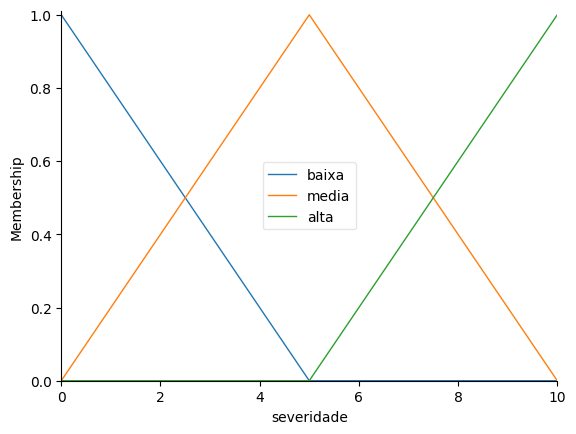

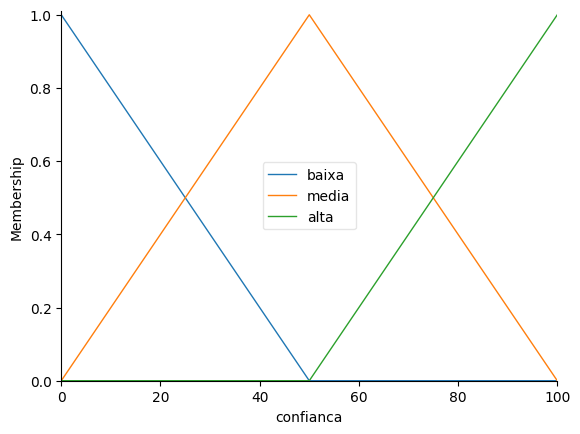

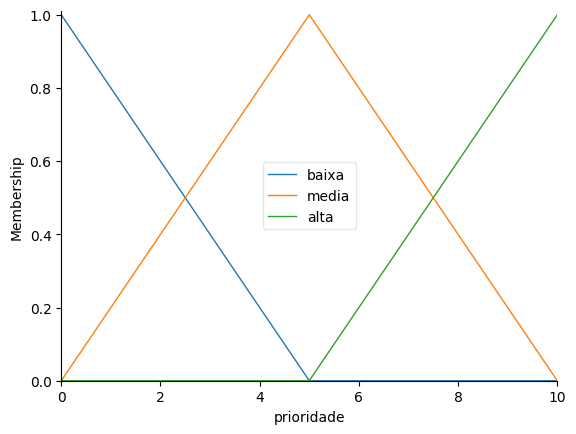

In [13]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

severidade = ctrl.Antecedent(np.arange(0, 10.01, 0.1), "severidade")
confianca = ctrl.Antecedent(np.arange(0, 100.01, 1), "confianca")
prioridade = ctrl.Consequent(np.arange(0, 10.01, 0.1), "prioridade")

severidade["baixa"] = fuzz.trimf(severidade.universe, [0, 0, 5])
severidade["media"] = fuzz.trimf(severidade.universe, [0, 5, 10])
severidade["alta"] = fuzz.trimf(severidade.universe, [5, 10, 10])

confianca["baixa"] = fuzz.trimf(confianca.universe, [0, 0, 50])
confianca["media"] = fuzz.trimf(confianca.universe, [0, 50, 100])
confianca["alta"] = fuzz.trimf(confianca.universe, [50, 100, 100])

prioridade["baixa"] = fuzz.trimf(prioridade.universe, [0, 0, 5])
prioridade["media"] = fuzz.trimf(prioridade.universe, [0, 5, 10])
prioridade["alta"] = fuzz.trimf(prioridade.universe, [5, 10, 10])

severidade.view()
confianca.view()
prioridade.view()

### Base de regras

9 regras, uma para cada combinacao das 3x3 possibilidades de `severidade` x
`confianca`, entao nenhum ponto do espaco de entrada fica sem regra que o
cubra:

| severidade \ confianca | baixa | media | alta |
| --- | --- | --- | --- |
| **baixa** | baixa | baixa | media |
| **media** | baixa | media | alta |
| **alta** | media | alta | alta |

In [14]:
regras = [
    ctrl.Rule(severidade["baixa"] & confianca["baixa"], prioridade["baixa"]),
    ctrl.Rule(severidade["baixa"] & confianca["media"], prioridade["baixa"]),
    ctrl.Rule(severidade["baixa"] & confianca["alta"], prioridade["media"]),
    ctrl.Rule(severidade["media"] & confianca["baixa"], prioridade["baixa"]),
    ctrl.Rule(severidade["media"] & confianca["media"], prioridade["media"]),
    ctrl.Rule(severidade["media"] & confianca["alta"], prioridade["alta"]),
    ctrl.Rule(severidade["alta"] & confianca["baixa"], prioridade["media"]),
    ctrl.Rule(severidade["alta"] & confianca["media"], prioridade["alta"]),
    ctrl.Rule(severidade["alta"] & confianca["alta"], prioridade["alta"]),
]

sistema = ctrl.ControlSystem(regras)


def priorizar(sev, conf):
    sim = ctrl.ControlSystemSimulation(sistema)
    sim.input["severidade"] = sev
    sim.input["confianca"] = conf
    sim.compute()
    return sim.output["prioridade"]

## Crisp (v1) x fuzzy (v2), lado a lado

O mesmo cenario de `demo()` — os tres hosts declarados na secao "Cenario da
memoria de trabalho" — roda pelas duas leituras: a decisao crisp que o motor
de regras ja tinha tomado em `motor`, e a prioridade fuzzy calculada em cima
da mesma evidencia bruta.

In [15]:
_evidencia = {
    "10.0.0.66": dict(portas=512, tentativas_login=47, bytes_saida=1_000, hora=3, hash_mudou=True),
    "10.0.0.20": dict(portas=3, tentativas_login=0, bytes_saida=900_000_000, hora=2, hash_mudou=False),
    "10.0.0.5": dict(portas=2, tentativas_login=1, bytes_saida=1_000, hora=14, hash_mudou=False),
}
_decisoes_crisp = _acoes_por_alvo(motor)

print(f"{'host':<12} {'decisao crisp (v1)':<20} {'severidade':<11} {'confianca':<10} prioridade fuzzy (v2)")
for host, ev in _evidencia.items():
    sev = severidade_de(ev["portas"], ev["tentativas_login"], ev["bytes_saida"], ev["hora"], ev["hash_mudou"])
    conf = confianca_de(ev["portas"], ev["tentativas_login"], ev["bytes_saida"], ev["hora"], ev["hash_mudou"])
    prio = priorizar(sev, conf)
    decisao = _decisoes_crisp.get(host, "sem decisao")
    print(f"{host:<12} {decisao:<20} {sev:<11.2f} {conf:<10.1f} {prio:.2f}")

host         decisao crisp (v1)   severidade  confianca  prioridade fuzzy (v2)
10.0.0.66    ISOLAR               7.00        70.0       5.38
10.0.0.20    MONITORAR            3.06        40.0       4.65
10.0.0.5     sem decisao          0.24        0.0        1.67


## Autoverificacao fuzzy

Mesma logica de v1: extremos opostos do dominio produzem prioridades nos
extremos opostos, o ponto central fica perto do meio, e a ordem das
prioridades fuzzy concorda com a severidade das decisoes crisp que o motor
de regras ja tinha tomado para o mesmo cenario (`ISOLAR` > `MONITORAR` >
sem decisao).

In [16]:
def _autoverificar_fuzzy():
    baixa = priorizar(0, 0)
    alta = priorizar(10, 100)
    media = priorizar(5, 50)

    assert baixa < 3, baixa
    assert alta > 7, alta
    assert 3 <= media <= 7, media
    assert alta > baixa

    prio_isolar = priorizar(
        severidade_de(**_evidencia["10.0.0.66"]), confianca_de(**_evidencia["10.0.0.66"])
    )
    prio_monitorar = priorizar(
        severidade_de(**_evidencia["10.0.0.20"]), confianca_de(**_evidencia["10.0.0.20"])
    )
    prio_sem_decisao = priorizar(
        severidade_de(**_evidencia["10.0.0.5"]), confianca_de(**_evidencia["10.0.0.5"])
    )
    assert prio_isolar > prio_monitorar > prio_sem_decisao, (
        prio_isolar, prio_monitorar, prio_sem_decisao
    )
    print("autoverificacao fuzzy ok")


_autoverificar_fuzzy()

autoverificacao fuzzy ok
